# 1 month salt budget test for ACCESS-OM2-01

Using **01deg_jra55v13_ryf9091_21mbath_copy** experiment (note it's NOT the _test one).
  
This notebook is currently a work in progress (converting salt budget code to freshwater budget). 

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)


# Importing data
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_copy-15025726/output040/ocean/ocean.nc'))
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_copy-15025726/output040/ocean/ocean_month.nc'))

In [3]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['pme_river','pme_net','pme_correct','river','wfimelt','wfiform','fprec','lprec','evap','runoff']].sel(yt_ocean=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['salt']].sel(yt_ocean=lat_slice)
    return ds

data_1 = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto')#,decode_times=False)
data_2 = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto')#,decode_times=False)

In [4]:
data_1

<xarray.Dataset> Size: 66MB
Dimensions:      (time: 1, yt_ocean: 460, xt_ocean: 3600)
Coordinates:
  * time         (time) object 8B 1910-01-16 12:00:00
  * yt_ocean     (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean     (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.85 79.95
Data variables:
    pme_river    (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    pme_net      (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    pme_correct  (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    river        (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    wfimelt      (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    wfiform      (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    fprec        (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    lprec        (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    evap         (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
    runoff       (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
Attributes:
    filename:   ocean_month.nc
    title:      ACCESS-OM2-01
    grid_type:  mosaic
    grid_tile:  1
    history:    20260316T0434Z: /g/data/ik11/inputs/access-om2/bin/mppnccombi...

In [7]:
# Sea surface salinity - maybe not needed
SSS = data_2.salt.isel(st_ocean=0)

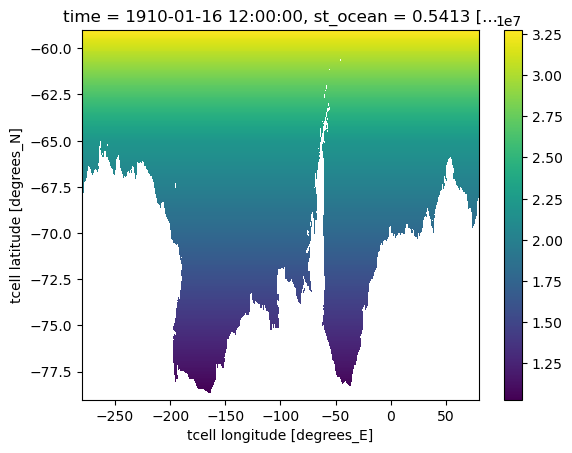

In [12]:
# Doing spatial average
area = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['area_t']
area_corr = area*(SSS*0 +1)
area_corr.plot()

In [13]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [14]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

In [16]:
# Shelf only 
pme_net = data_1.pme_net.where(shelf_mask == 1)
pme_river = data_1.pme_river.where(shelf_mask == 1)
river = data_1.river.where(shelf_mask == 1)
wfimelt = data_1.wfimelt.where(shelf_mask == 1)
wfiform = data_1.wfiform.where(shelf_mask == 1)
melt = (wfiform + wfimelt).where(shelf_mask == 1)

In [27]:
# Spatial average
pme_net_ave = (area_corr * pme_net).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
pme_river_ave = (area_corr * pme_river).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
river_ave = (area_corr * river).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
wfimelt_ave = (area_corr * wfimelt).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
wfiform_ave = (area_corr * wfiform).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
melt_ave = (area_corr * melt).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])

In [29]:
pme_net_ave = pme_net_ave.squeeze().load()
pme_river_ave = pme_river_ave.squeeze().load()
river_ave = river_ave.squeeze().load()
wfimelt_ave = wfimelt_ave.squeeze().load()
wfiform_ave = wfiform_ave.squeeze().load()
melt_ave = melt_ave.squeeze().load()

The surface FW budget is given by:  
PME_RIVER = RIVER + MELT (wfiform+wfimelt) + PME (pme_net - (wfiform+wfimelt)) 

In [43]:
# Term labels
terms = [
    "pme_river",
    "pme_net",
    "river",
    "wfimelt",
    "wfiform",
    "melt",
    "budget"
]

# Anomaly values
control = [
    pme_river_ave.values,
    pme_net_ave.values,
    river_ave.values,
    wfimelt_ave.values,
    wfiform_ave.values,
    melt_ave.values,
    (river_ave + melt_ave + (pme_net_ave - melt_ave)).values
]

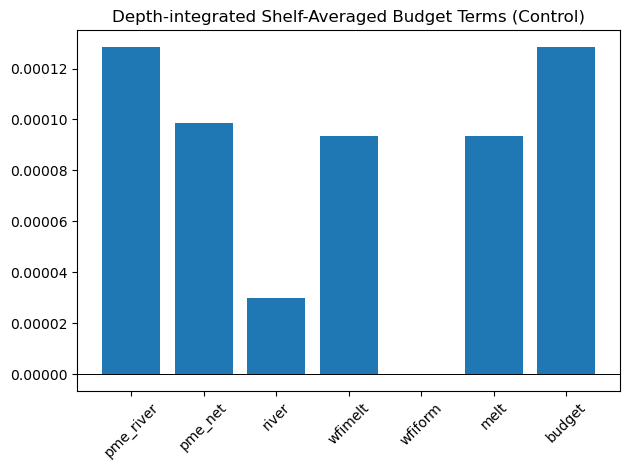

In [44]:
# Create figure
plt.figure()
plt.bar(terms, control)

#plt.ylim(-0.25e-5,2.5e-5)
plt.axhline(0, color='black', linewidth=0.7)
plt.title("Depth-integrated Shelf-Averaged Budget Terms (Control)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Note - what has happened to `wfiform` and how can sea ice formation be included in the budget if it is not saved into this variable?

In [42]:
# Checking closure
budget = (river_ave + melt_ave + (pme_net_ave - melt_ave))
residual = pme_river_ave - budget
residual

<xarray.DataArray ()> Size: 4B
array(-1.4551915e-11, dtype=float32)
Coordinates:
    time      object 8B 1910-01-16 12:00:00
    st_ocean  float64 8B 0.5413

This looks pretty closed to me.